LANGKAH 1: Membaca file Biner GGMplus...
✅ Total data: 6250000 titik. Dimensi matriks: 2500 x 2500
LANGKAH 2: Memotong data sesuai area Tampomas...
------------------------------
✅ STATISTIK DATA TAMPOMAS:
Jumlah titik : 90000
Min mGal     : 112.20
Max mGal     : 315.80
------------------------------
✅ File berhasil disimpan di: D:/semester_6/Metode_Potensial/Metode-Potensial/data/proses/tampomas_dg_potong.csv


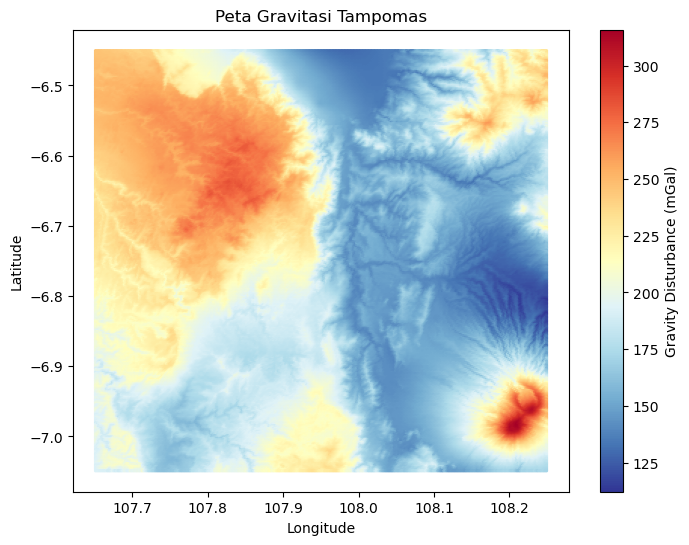

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

file_dg = "D:/semester_6/Metode_Potensial/Metode-Potensial/data/mentah/jawabarat.dg" 

# Koordinat Area Proyek Tampomas
lat_min_target, lat_max_target = -7.05, -6.45
lon_min_target, lon_max_target = 107.65, 108.25

print("LANGKAH 1: Membaca file Biner GGMplus...")
if not os.path.exists(file_dg):
    print(f"❌ File {file_dg} tidak ditemukan!")
else:
    try:
        # PERBAIKAN FATAL: GGMplus .dg menggunakan format Integer 16-bit (2-byte)
        # Standar datanya adalah Big-Endian ('>i2')
        data_1d = np.fromfile(file_dg, dtype='>i2')
        
        n_points = len(data_1d)
        n_side = int(np.sqrt(n_points))
        
        # Sekarang pasti jumlahnya 6.250.000 titik, dan n_side adalah 2500
        print(f"✅ Total data: {n_points} titik. Dimensi matriks: {n_side} x {n_side}")
        
        # KONVERSI KE mGal: 
        # Dokumentasi GGMplus menyatakan nilai integer harus dikali 0.1
        data_mgal = data_1d.astype(float) * 0.1
        
        # FILTER DATA KOSONG: 
        # GGMplus memakai angka -32768 (-2^15) untuk area tanpa data
        data_mgal[data_mgal < -3000] = np.nan
        
        # Reshape menjadi matriks 2D
        data_2d = data_mgal.reshape((n_side, n_side))

        # 3. MEMBUAT KOORDINAT UNTUK SELURUH TILE (S10E105)
        # S10E105 mencakup: Latitude -5 s/d -10, Longitude 105 s/d 110
        # Di GGMplus, matriks selalu dimulai dari Utara ke Selatan, Barat ke Timur
        lats = np.linspace(-5.0, -10.0, n_side) 
        lons = np.linspace(105.0, 110.0, n_side)
        lon_grid, lat_grid = np.meshgrid(lons, lats)

        print("LANGKAH 2: Memotong data sesuai area Tampomas...")
        # Teknik Masking agar tidak perlu pusing menghitung indeks baris/kolom
        mask = (lat_grid >= lat_min_target) & (lat_grid <= lat_max_target) & \
               (lon_grid >= lon_min_target) & (lon_grid <= lon_max_target)

        df_potong = pd.DataFrame({
            'longitude': lon_grid[mask],
            'latitude': lat_grid[mask],
            'gravity_dist': data_2d[mask]
        }).dropna() # Buang data yang NaN

        print("-" * 30)
        print(f"✅ STATISTIK DATA TAMPOMAS:")
        print(f"Jumlah titik : {len(df_potong)}")
        print(f"Min mGal     : {df_potong['gravity_dist'].min():.2f}")
        print(f"Max mGal     : {df_potong['gravity_dist'].max():.2f}")
        print("-" * 30)

        # 4. SIMPAN & VISUALISASI
        path_output = "D:/semester_6/Metode_Potensial/Metode-Potensial/data/proses/tampomas_dg_potong.csv"
        df_potong.to_csv(path_output, index=False)
        print(f"✅ File berhasil disimpan di: {path_output}")

        plt.figure(figsize=(8, 6))
        plt.scatter(df_potong['longitude'], df_potong['latitude'], 
                    c=df_potong['gravity_dist'], cmap='RdYlBu_r', s=2)
        plt.colorbar(label='Gravity Disturbance (mGal)')
        plt.title("Peta Gravitasi Tampomas")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        
        # Format angka koordinat agar tidak menjadi scientific notation (1e6)
        plt.gca().ticklabel_format(useOffset=False, style='plain')
        
        plt.show()

    except Exception as e:
        print(f"❌ Terjadi kesalahan: {e}")